In [1]:
import pickle
import torch
from tqdm import tqdm
from minf.data import FieldDataset
from minf.models import Autoencoder, SirenNet
from minf.utils import plot_field
from torch.utils.data import DataLoader
import numpy as np
import yt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd

from rdkit import Chem
from rdkit.Chem import rdMolDescriptors

In [2]:
resolution = 16

df = pd.read_csv("../data/bace.csv")

smiles = df["smiles"].tolist()

fd = FieldDataset(smiles, resolution=resolution)
dl = DataLoader(fd, batch_size=4, shuffle=True)
dl_test = DataLoader(fd, batch_size=8, shuffle=False)

In [3]:
net = SirenNet(
    dim_in=4,
    dim_hidden=512,
    dim_out=1,
    num_layers=8,
    w0 = 1.0,
    w0_initial = 30.0,
    use_bias = True,
    final_activation = None
)

autoencoder = Autoencoder(
    net,
    in_channels=10,
    output_shape=[resolution, resolution, resolution, 10, 1],
    latent_dim=512,
)

autoencoder.cuda()

optim = torch.optim.Adam(lr=1e-4, params=autoencoder.parameters())

# Load the model
autoencoder.load_state_dict(torch.load("../models/bace.pt", weights_only=True))
autoencoder.cuda()

/home/daenu/micromamba/envs/minf/lib/python3.11/site-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3595.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Autoencoder(
  (net): SirenNet(
    (layers): ModuleList(
      (0-7): 8 x Siren(
        (activation): Sine()
      )
    )
    (last_layer): Siren(
      (activation): Identity()
    )
  )
  (encoder): Encoder(
    (in_layer): Conv3d(10, 20, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (bn_input): BatchNorm3d(20, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (layer_1): Conv3d(20, 40, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (bn_1): BatchNorm3d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (out_layer): Conv3d(40, 512, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (bn_output): BatchNorm3d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (pooling): AdaptiveAvgPool3d(output_size=1)
  )
  (modulator): Modulator(
    (layers): ModuleList(
      (0): Sequential(
        (0): Linear(in_features=512, out_features=512, bias=True)
        (1): ReLU()
      )
      

In [4]:
x = []
for batch in tqdm(dl_test, total=len(dl_test)):
    latents = autoencoder.encode(batch.cuda())
    predictions = autoencoder.predict(latents)

    for latent in latents:
        x.append(latent.cpu().detach().numpy())
    if len(x) % 100 == 0:
        print(len(x))
    break

  0%|                                                                                                                                                                                                                                                              | 0/190 [00:01<?, ?it/s]


OutOfMemoryError: CUDA out of memory. Tried to allocate 640.00 MiB. GPU 0 has a total capacity of 11.84 GiB of which 536.75 MiB is free. Including non-PyTorch memory, this process has 10.42 GiB memory in use. Of the allocated memory 10.18 GiB is allocated by PyTorch, and 14.60 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

 13%|█████████████▌                                                                                         | 25/190 [00:18<00:45,  3.65it/s]

200


 26%|███████████████████████████                                                                            | 50/190 [00:37<01:41,  1.39it/s]

400


 39%|████████████████████████████████████████▋                                                              | 75/190 [00:53<01:07,  1.70it/s]

...

 79%|████████████████████████████████████████████████████████████████████████████████▌                     | 150/190 [01:33<00:20,  1.96it/s]

1200


 92%|█████████████████████████████████████████████████████████████████████████████████████████████▉        | 175/190 [01:47<00:09,  1.55it/s]

1400


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 190/190 [01:53<00:00,  1.67it/s]


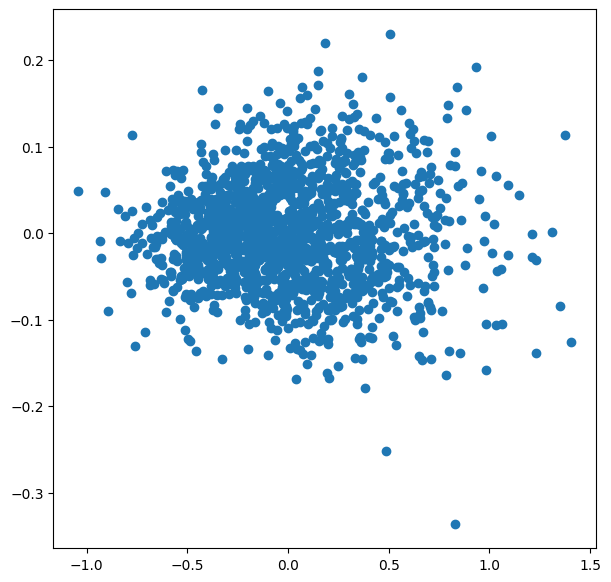

In [11]:
x = []
for batch in tqdm(dl_test, total=len(dl_test)):
    latents = autoencoder.encode(batch.cuda())
    for latent in latents:
        x.append(latent.cpu().detach().numpy())
    if len(x) % 100 == 0:
        print(len(x))

x_pc = PCA(n_components=2).fit_transform(x)

fig, ax = plt.subplots(figsize=(7, 7))

# for i, coord in enumerate(x_pc):
#     ax.text(coord[0], 
#             coord[1], 
#             str(y[i]), fontsize=18)

ax.scatter(x_pc.T[0], x_pc.T[1])

In [14]:
df

,smiles,CID,Class,Model,pIC50,MW,AlogP,HBA,HBD,RB,...,PEOE6 (PEOE6),PEOE7 (PEOE7),PEOE8 (PEOE8),PEOE9 (PEOE9),PEOE10 (PEOE10),PEOE11 (PEOE11),PEOE12 (PEOE12),PEOE13 (PEOE13),PEOE14 (PEOE14),canvasUID
0,O1CC[C@@H](NC(=O)[C@@H](Cc2cc3cc(ccc3nc2N)-c2c...,BACE_1,1,Train,9.154901,431.56979,4.4014,3,2,5,...,53.205711,78.640335,226.855410,107.434910,37.133846,0.000000,7.980170,0.000000,0.000000,1
1,Fc1cc(cc(F)c1)C[C@H](NC(=O)[C@@H](N1CC[C@](NC(...,BACE_2,1,Train,8.853872,657.81073,2.6412,5,4,16,...,73.817162,47.171600,365.676940,174.076750,34.923889,7.980170,24.148668,0.000000,24.663788,2
2,S1(=O)(=O)N(c2cc(cc3c2n(cc3CC)CC1)C(=O)N[C@H](...,BACE_3,1,Train,8.698970,591.74091,2.5499,4,3,11,...,70.365707,47.941147,192.406520,255.752550,23.654478,0.230159,15.879790,0.000000,24.663788,3
3,S1(=O)(=O)C[C@@H](Cc2cc(O[C@H](COCC)C(F)(F)F)c...,BACE_4,1,Train,8.698970,591.67828,3.1680,4,3,12,...,56.657166,37.954151,194.353040,202.763350,36.498634,0.980913,8.188327,0.000000,26.385181,4
4,S1(=O)(=O)N(c2cc(cc3c2n(cc3CC)CC1)C(=O)N[C@H](...,BACE_5,1,Train,8.698970,629.71283,3.5086,3,3,11,...,78.945702,39.361153,179.712880,220.461300,23.654478,0.230159,15.879790,0.000000,26.100143,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1508,Clc1cc2nc(n(c2cc1)C(CC(=O)NCC1CCOCC1)CC)N,BACE_1543,0,Test,3.000000,364.86969,2.5942,3,2,6,...,37.212799,37.681076,180.226410,95.670128,30.107586,9.368159,7.980170,0.000000,0.000000,1543
1509,Clc1cc2nc(n(c2cc1)C(CC(=O)NCc1ncccc1)CC)N,BACE_1544,0,Test,3.000000,357.83731,2.8229,3,2,6,...,45.792797,47.349350,122.401500,99.877144,30.107586,9.368159,7.980170,0.000000,0.000000,1544
1510,Brc1cc(ccc1)C1CC1C=1N=C(N)N(C)C(=O)C=1,BACE_1545,0,Test,2.953115,320.18451,3.0895,2,1,2,...,47.790600,22.563574,96.290794,58.798935,20.071724,9.368159,0.000000,6.904104,0.000000,1545
1511,O=C1N(C)C(=NC(=C1)C1CC1c1cc(ccc1)-c1ccccc1)N,BACE_1546,0,Test,2.733298,317.38440,3.8595,2,1,3,...,77.219978,9.316234,95.907784,112.609720,20.071724,9.368159,0.000000,6.904104,0.000000,1546


0


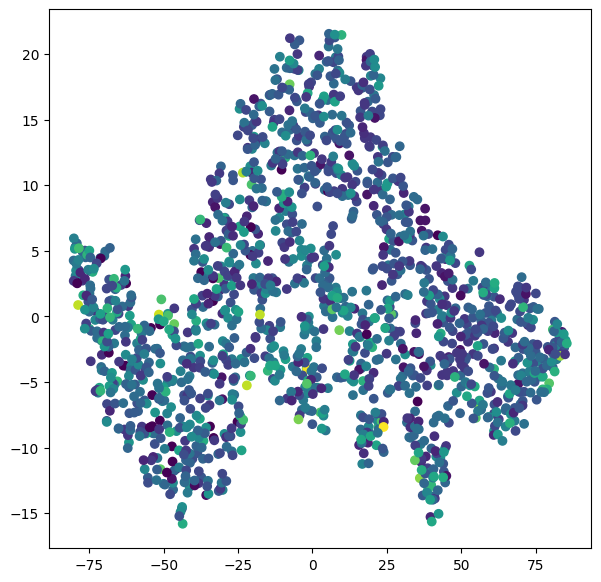

In [19]:
for i in range(1):
    print(i)
    y = df["PEOE6 (PEOE6)"].tolist()
    # for smi in df["smiles"].tolist():
    #     mol = Chem.MolFromSmiles(smi)
    #     y.append(rdMolDescriptors.MQNs_(mol)[i])

    x_pc = TSNE(n_components=2).fit_transform(np.array(x))

    fig, ax = plt.subplots(figsize=(7, 7))

    # for i, coord in enumerate(x_pc):
    #     ax.text(coord[0], 
    #             coord[1], 
    #             str(y[i]), fontsize=18)

    ax.scatter(x_pc.T[0], x_pc.T[1], c=y)
    plt.show()